# EDA for the Faces Dataset

In [10]:
import os

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
import random

from PIL import Image
import cv2
from collections import defaultdict

Display the number of images per model and class

In [11]:
base_path = "../data"
fake_base_path = os.path.join(base_path, "fake")
real_path = os.path.join(base_path, "ffhq")
image_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.gif')

real_images = [f for f in os.listdir(real_path) if f.lower().endswith(image_extensions)]
real_count = len(real_images)

fake_counts = {}
sfhq_subcounts = {}
total_fake = 0

for subfolder in os.listdir(fake_base_path):
    subfolder_path = os.path.join(fake_base_path, subfolder)

    if not os.path.isdir(subfolder_path):
        continue

    if subfolder == "sfhq":
        sfhq_total = 0
        for nested in os.listdir(subfolder_path):
            nested_path = os.path.join(subfolder_path, nested)
            if os.path.isdir(nested_path):
                count = len([
                    f for f in os.listdir(nested_path)
                    if f.lower().endswith(image_extensions)
                ])
                sfhq_subcounts[nested] = count
                sfhq_total += count
        fake_counts["sfhq"] = sfhq_total
        total_fake += sfhq_total

    else:
        images = [f for f in os.listdir(subfolder_path) if f.lower().endswith(image_extensions)]
        count = len(images)
        fake_counts[subfolder] = count
        total_fake += count

total_images = real_count + total_fake
real_percentage = (real_count / total_images) * 100 if total_images > 0 else 0
fake_percentage = (total_fake / total_images) * 100 if total_images > 0 else 0

# --- Output ---
print(f"Real images (ffhq): {real_count}\n")

print(f"AI-generated image breakdown:")
for subfolder, count in fake_counts.items():
    percentage = (count / total_fake) * 100 if total_fake > 0 else 0
    print(f"  - {subfolder}: {count} images ({percentage:.2f}%)")

print(f"\n🔍 Breakdown inside 'sfhq':")
for nested, count in sfhq_subcounts.items():
    print(f"  - {nested}: {count} images")

print(f"\nDataset Summary:")
print(f"  Total AI-generated images: {total_fake}")
print(f"  Total real images: {real_count}")
print(f"  Total images: {total_images}")
print(f"  % Real: {real_percentage:.2f}%")
print(f"  % AI-generated: {fake_percentage:.2f}%")

Real images (ffhq): 70000

AI-generated image breakdown:
  - thispersondoesnotexist: 20499 images (40.23%)
  - sfhq: 20000 images (39.25%)
  - faceswap: 9429 images (18.50%)
  - stable_diffusion: 1031 images (2.02%)

🔍 Breakdown inside 'sfhq':
  - pt3: 5000 images
  - pt4: 5000 images
  - pt2: 5000 images
  - pt1: 5000 images

Dataset Summary:
  Total AI-generated images: 50959
  Total real images: 70000
  Total images: 120959
  % Real: 57.87%
  % AI-generated: 42.13%


## Image Quality and Pixel Color Analysis

We will now perform some basic exploratory data analysis (EDA) on the datasets. This will help us understand the distribution of images across different diffusion models and classes.

We will focus on 3 key aspects of evaluating and comparing the quality of our images across classes (AI generated or not) for the faces dataset:

1. Color and Pixel-Level Analysis
We will compute the average color histograms (RGB channels) for each group in order to compare the mean pixel intensity per class and the RGB channel distribution. We will also compute the color channel correlation matrix to see how the color channels are correlated with each other. This will help us understand the color distribution of the images and how they differ across classes.

2. Image Quality Analysis
We will compute the average Laplacian variance and noise levels for each group in order to compare the mean image quality per class. This will help us understand the image quality of the images and how they differ across classes.

3. Fast Fourier Transform Analysis (FFT)
We will compute the Fourier transform of the images and plot the frequency domain representation for each group. This will help us understand the frequency distribution of the images and how they differ across classes.

### Selecting a subset of the data

In [12]:
base_path = '../data_resized'
subset_path = '../data_subset'
os.makedirs(subset_path, exist_ok=True)
class_names = {0: 'Real', 1: 'AI'}

n_images = 500

for label, class_name in class_names.items():
    class_dir = os.path.join(base_path, str(label))
    subset_class_dir = os.path.join(subset_path, str(label))
    os.makedirs(subset_class_dir, exist_ok=True)

    all_files = os.listdir(class_dir)
    selected_files = random.sample(all_files, min(n_images, len(all_files)))

    for file_name in selected_files:
        src_file = os.path.join(class_dir, file_name)
        dst_file = os.path.join(subset_class_dir, file_name)
        shutil.copy2(src_file, dst_file)

print("Subset created in:", subset_path)

Subset created in: ../data_subset


#### A. Average Color Histograms (RBG Channels)

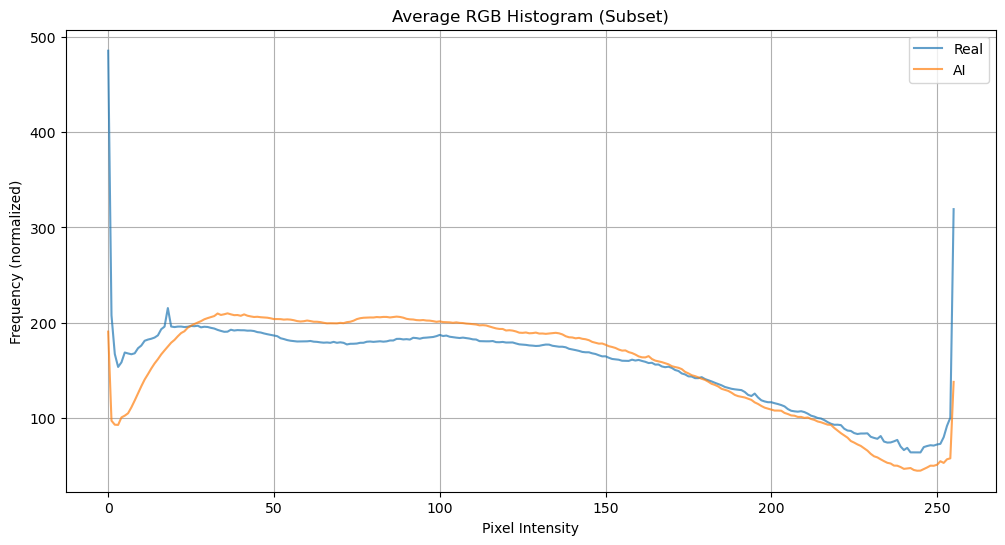

Real - Mean RGB: [130.08 107.14  94.7 ]
AI - Mean RGB: [127.61 106.62  94.06]


In [13]:
mean_colors = {}
all_histograms = {}

for class_id in [0, 1]:
    class_path = os.path.join(subset_path, str(class_id))
    pixel_values = []
    histograms = []

    for filename in os.listdir(class_path):
        filepath = os.path.join(class_path, filename)
        try:
            img = Image.open(filepath).convert("RGB")
            img_np = np.array(img)

            for c in range(3):  # RGB
                hist, _ = np.histogram(img_np[..., c], bins=256, range=(0, 256))
                histograms.append(hist)

            pixel_values.append(img_np)

        except Exception as e:
            print(f"Skipping {filepath}: {e}")

    if pixel_values:
        pixel_values = np.stack(pixel_values)
        mean_pixel = pixel_values.mean(axis=(0, 1, 2))
        mean_colors[class_id] = mean_pixel
        histograms = np.array(histograms).reshape(-1, 256)
        mean_histogram = histograms.mean(axis=0)
        all_histograms[class_id] = mean_histogram
    else:
        print(f"No valid images found in class {class_id}")

plt.figure(figsize=(12, 6))
colors = ['red', 'green', 'blue']
for class_id, hist in all_histograms.items():
    plt.plot(hist, label=f'{class_names[class_id]}', alpha=0.7)
plt.title('Average RGB Histogram (Subset)')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency (normalized)')
plt.legend()
plt.grid()
plt.show()

for class_id, mean_color in mean_colors.items():
    print(f"{class_names[class_id]} - Mean RGB: {mean_color.round(2)}")


#### B. Color Channel Correlation Matrix

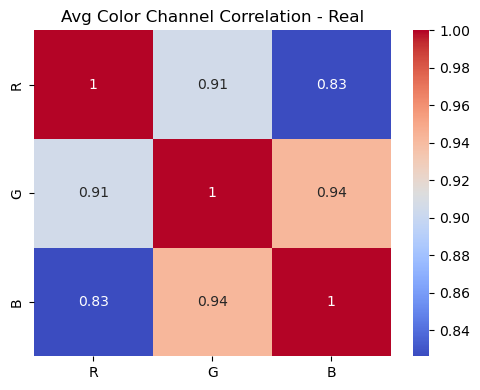

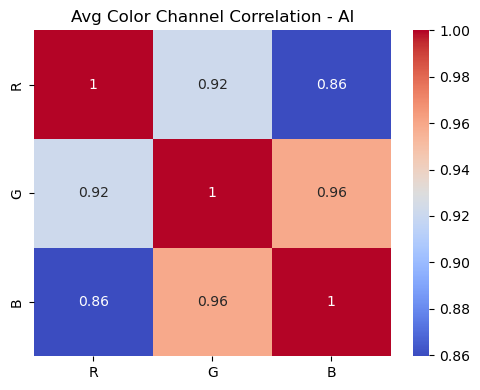

In [14]:
avg_corr_matrices = {}

for class_id in [0, 1]:
    class_path = os.path.join(subset_path, str(class_id))
    corr_matrices = []

    for filename in os.listdir(class_path):
        filepath = os.path.join(class_path, filename)
        try:
            img = Image.open(filepath).convert("RGB")
            img_np = np.array(img)

            h, w, _ = img_np.shape
            reshaped = img_np.reshape(-1, 3)
            corr_matrix = np.corrcoef(reshaped.T)

            corr_matrices.append(corr_matrix)

        except Exception as e:
            print(f"Skipping {filepath}: {e}")

    avg_corr_matrix = np.mean(corr_matrices, axis=0)
    avg_corr_matrices[class_id] = avg_corr_matrix

    plt.figure(figsize=(5, 4))
    sns.heatmap(avg_corr_matrix, annot=True, cmap="coolwarm", xticklabels=["R", "G", "B"], yticklabels=["R", "G", "B"])
    plt.title(f"Avg Color Channel Correlation - {class_names[class_id]}")
    plt.tight_layout()
    plt.show()

#### C. Image Bluriness (Laplacian Variance)

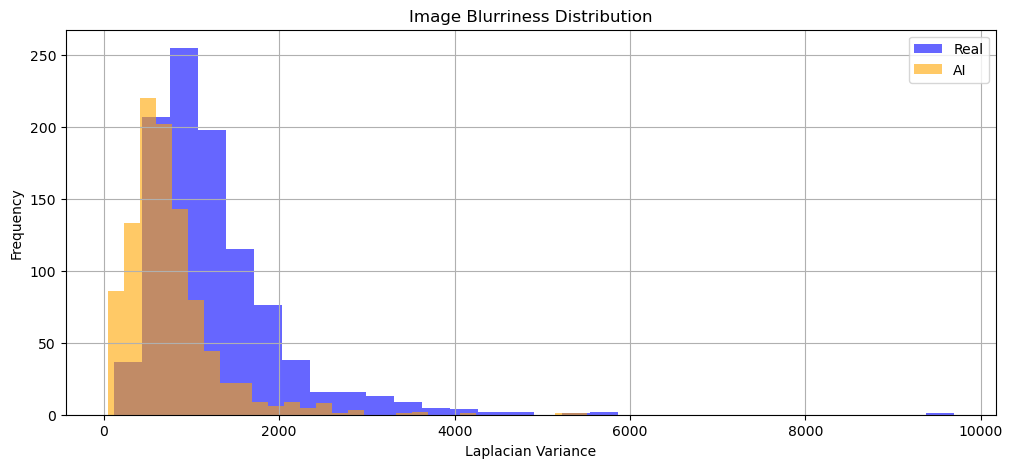

In [15]:
blurriness_scores = {0: [], 1: []}

def calculate_blurriness(img_gray):
    # higher → sharper, lower → blurrier
    return cv2.Laplacian(img_gray, cv2.CV_64F).var()

for class_id in [0, 1]:
    class_path = os.path.join(subset_path, str(class_id))

    for filename in os.listdir(class_path):
        filepath = os.path.join(class_path, filename)
        try:
            img = cv2.imread(filepath)
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            blurriness = calculate_blurriness(gray)
            blurriness_scores[class_id].append(blurriness)
        except Exception as e:
            print(f"Skipping {filepath}: {e}")

plt.figure(figsize=(12, 5))
plt.hist(blurriness_scores[0], bins=30, alpha=0.6, label='Real', color='blue')
plt.hist(blurriness_scores[1], bins=30, alpha=0.6, label='AI', color='orange')
plt.title("Image Blurriness Distribution")
plt.xlabel("Laplacian Variance")
plt.ylabel("Frequency")
plt.legend()
plt.grid()
plt.show()

#### D. Image Noisiness

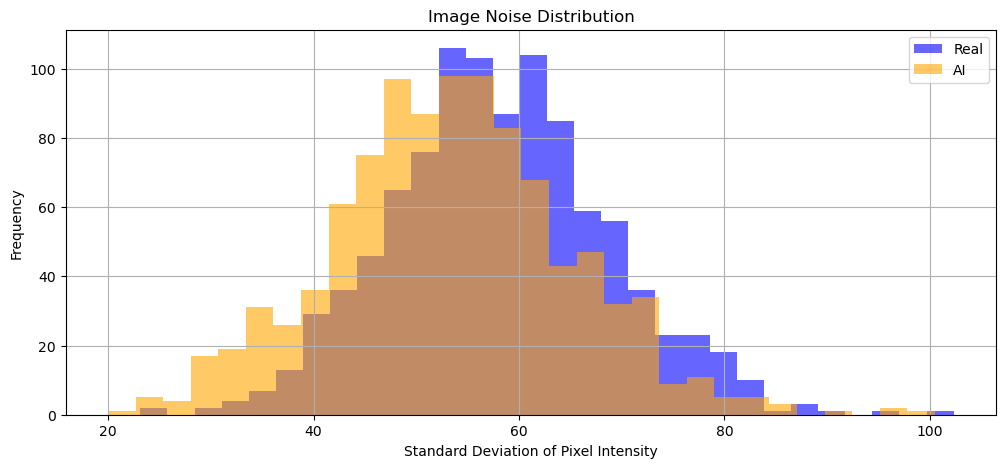

In [16]:
noise_scores = {0: [], 1: []}

for class_id in [0, 1]:
    class_path = os.path.join(subset_path, str(class_id))

    for filename in os.listdir(class_path):
        filepath = os.path.join(class_path, filename)
        try:
            img = cv2.imread(filepath)
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            noise = np.std(gray)
            noise_scores[class_id].append(noise)
        except Exception as e:
            print(f"Skipping {filepath}: {e}")

plt.figure(figsize=(12, 5))
plt.hist(noise_scores[0], bins=30, alpha=0.6, label='Real', color='blue')
plt.hist(noise_scores[1], bins=30, alpha=0.6, label='AI', color='orange')
plt.title("Image Noise Distribution")
plt.xlabel("Standard Deviation of Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()
plt.grid()
plt.show()

#### E. Fast Fourier Transform (FFT)

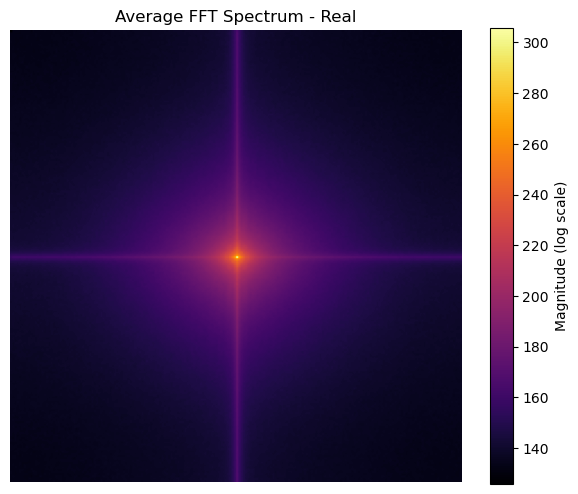

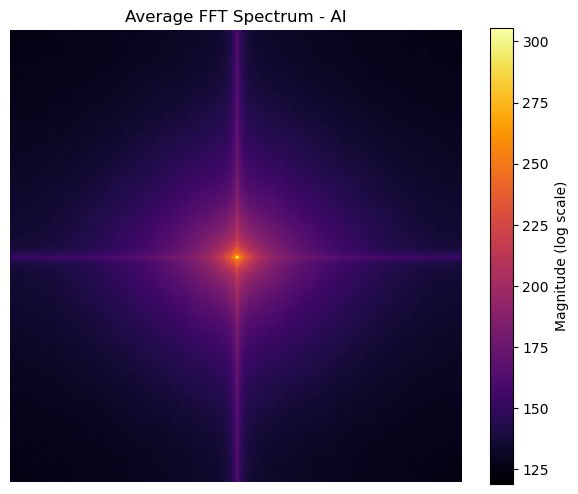

In [17]:
fft_magnitude_accumulator = {0: [], 1: []}

def compute_fft_magnitude(gray_img):
    f = np.fft.fft2(gray_img)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1e-8)  # because we were getting an error for log(0)
    return magnitude_spectrum

for class_id in [0, 1]:
    class_path = os.path.join(subset_path, str(class_id))

    for filename in os.listdir(class_path):
        filepath = os.path.join(class_path, filename)
        try:
            img = cv2.imread(filepath)
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            fft_magnitude = compute_fft_magnitude(gray)
            fft_magnitude_accumulator[class_id].append(fft_magnitude)

        except Exception as e:
            print(f"Skipping {filepath}: {e}")

for class_id in [0, 1]:
    if fft_magnitude_accumulator[class_id]:
        mean_fft = np.mean(fft_magnitude_accumulator[class_id], axis=0)

        plt.figure(figsize=(6, 5))
        plt.imshow(mean_fft, cmap='inferno')
        plt.title(f"Average FFT Spectrum - {class_names[class_id]}")
        plt.colorbar(label='Magnitude (log scale)')
        plt.axis('off')
        plt.tight_layout()
        plt.show()

From the average RGB histograms, we notice that AI generated images have more average intensity pixels, while real images have more frequency around pixels that are either of 0 or 255 intensity. This could be due to the fact that real images tend to have more natural variation in color and lighting conditions, while AI generated images may be more consistent in their color distribution.

From the color channel correlation matrix, we observe that the correlation coefficients are always slightly higher for AI generated images, i.e. the color channels are more correlated with each other. This could be due again to the fact that AI generated images tend to have more consistent color distributions, while real images may have more variation in color and lighting conditions.

From the image bluriness distribution, we observe that even though there is some overlap, the AI images are generally less blurry and the real images have a wider range of sharpness (longer tail), which suggests more natural variation in real photos.

From the image noise distribution, the overlap is higher, but we observe again a slight difference between AI having a lower noise and Real images which have a higher noise level. This makes sense with the fact that real images tend to contain more natural variation or "imperfections" in pixel intensity. This feature/effect might be harder for AI generators to grasp and replicate, which explains the lower noise as well.

Laslty, for the Fast Fourier Transform (FFT) analysis, we observe that the AI generated images have a very slightly higher magnitude than the real images. This makes sense with the previous observations as well.

Overall, these could be good features to use in a classification task to distinguish between AI and real images. However, we should be careful with the interpretation of these results, as they are not definitive and could be influenced by other factors such as the specific models used for generation or the dataset itself. 

### Comparing these plots for all three datasets already give us different distribution results??

## Pixel Normalization

Lastly, we will normalise the pixels of our images as it is a common preprocessing step in image deep learning tasks. However, we will not perform this step now as the normalisation will be done in the model building milestone of the project, since the range we will bring our pixels' values to will depend on the model we choose (ex [0, 1] or [-1, 1]).

ResNet etc. also different, and they have their own normalization included. ImageNet mean and standard deviation.